In [3]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
from src.data_loading import load_snapshot, inventory_summary

df = load_snapshot("../data/raw/snapshot_eoa_nic.csv")
inventory_summary(df)
df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[load_snapshot] loaded 2031 rows, 24 cols (encoding=utf-8-sig, sep=',')

=== SNAPSHOT INVENTORY SUMMARY ===
Total meters (rows): 2031
Unique device SNs:   2031
Meters with a name:  3
  example names: WBN Warehouse, Meniko School
Meters with an alarm flag: 701
  alarm types seen:
     272  Leakage Of Device,Logic Leakage Alarm
     157  Leakage Of Device
     138  Air Tube
     132  Logic Leakage Alarm
       1  Battery Low,Leakage Of Device
       1  Transducer Error
  (1 timestamps could not be parsed -- check date format)
Last communication: newest=2026-06-16 09:36:55, oldest=2025-07-23 12:46:54
Meters silent >3 days vs newest: 9



,Device SN*,Last communication time,Normal Flow(m³),Back Flow(m³),Alarm,Flow Rate(m³/h),RSRP(dBm),Temperature(℃),Device Name,Contract No,...,City,Street,Street No,Flat No,Longitude,Latitude,Consumer Number,Remarks,Sleep Times,Communication Abnormality Times
0,20404098,2026-06-12 22:35:51,1018.025,0.237,NaN,0.000,-99,22.86,WBN Warehouse,NaN,...,WBN Warehouse,ΒΟΥΛΙΑΓΜΕΝΗΣ,1,NaN,33.377471,35.152904,8545.0,SYL Warehouse,5,4
1,202405101856,2026-06-15 19:11:06,511.481,0.000,"Leakage Of Device,Logic Leakage Alarm",0.010,-91,25.89,Meniko School,NaN,...,ΜΕΝΟΙΚΟ,ΜΑΝΑΣ ΤΩΝ ΠΑΙΔΩΝ,53,NaN,33.147098,35.113515,434.0,45/434 ΑΡΙΣΤΕΡΑ ΕΙΣΟΔΟΥ,1,1
2,202405101858,2026-06-15 09:56:08,312.157,2.379,NaN,0.002,-93,27.56,Meniko School,NaN,...,ΜΕΝΟΙΚΟ,ΜΑΝΑΣ ΤΩΝ ΠΑΙΔΩΝ,53,NaN,33.147202,35.113407,435.0,45/435 ΔΕΞΙΑ ΕΙΣΟΔΟΥ,1,1
3,202405100854,2026-05-30 15:08:16,34.186,0.022,NaN,0.000,-138,24.40,NaN,NaN,...,ΜΕΝΟΙΚΟ,ΑΓΙΟΥ ΚΥΠΡΙΑΝΟΥ,28,NaN,33.143924,35.109472,50.0,45/50-ΠΑΡΑΔΟΣΙΑΚΑ/ΕΚΚΛΗΣΙΑΣΤΙΚΑ ΕΙΔΗ,166,10
4,202405100853,2026-06-14 17:34:19,10.799,0.050,NaN,0.000,-134,29.30,NaN,NaN,...,ΜΕΝΟΙΚΟ,ΑΓΙΟΥ ΚΥΠΡΙΑΝΟΥ,26,NaN,33.143908,35.109448,49.0,45/49,171,6


In [5]:
import pandas as pd
ts = pd.to_datetime(df["Last communication time"], errors="coerce")
df[ts.isna()][["Device SN*", "Last communication time"]]

,Device SN*,Last communication time
2030,202505102012,NaN


In [8]:
import pandas as pd
df = pd.read_csv("../data/raw/meter_202405101132.csv", sep=None, engine="python")  
print(df.shape)
print(df.columns.tolist())
print(df.head(10))
df["deviceId"].value_counts()   # how many rows per meter (adjust column name)

(10441, 9)
['params', 'id', 'updateAt', 'deviceId', 'flow', 'dataTime', 'signalCsq', 'isWaring', 'paValue']
  params        id             updateAt      deviceId    flow  \
0     {}  47921556  2026-06-16 22:42:20  202405101132  86.911   
1     {}  47921555  2026-06-16 22:42:20  202405101132  86.890   
2     {}  47921554  2026-06-16 22:42:20  202405101132  86.890   
3     {}  47921553  2026-06-16 22:42:20  202405101132  86.889   
4     {}  47921552  2026-06-16 22:42:20  202405101132  86.889   
5     {}  47921551  2026-06-16 22:42:20  202405101132  86.879   
6     {}  47921550  2026-06-16 22:42:20  202405101132  86.810   
7     {}  47921549  2026-06-16 22:42:20  202405101132  86.810   
8     {}  47921548  2026-06-16 22:42:20  202405101132  86.810   
9     {}  47921547  2026-06-16 22:42:20  202405101132  86.810   

              dataTime  signalCsq isWaring  paValue  
0  2026-06-16 00:00:00          0      NaN      NaN  
1  2026-06-15 23:00:00          0      NaN      NaN  
2  2026-06-15 

deviceId
202405101132    10441
Name: count, dtype: int64

In [12]:
from src.data_loading import load_meter_csv, meter_check

m1 = load_meter_csv("../data/raw/meter_202405101132.csv")
m2 = load_meter_csv("../data/raw/meter_202405101935.csv")
m3 = load_meter_csv("../data/raw/meter_202405101899.csv")
m4 = load_meter_csv("../data/raw/meter_202405100909.csv")
m5 = load_meter_csv("../data/raw/meter_202405101891.csv")

[load_meter_csv] meter 202405101132: 10441 rows (2025-04-02 01:00:00 -> 2026-06-16 00:00:00)
[load_meter_csv] meter 202405101935: 8016 rows (2024-09-30 01:00:00 -> 2026-06-17 00:00:00)
[load_meter_csv] meter 202405101899: 7992 rows (2024-09-30 01:00:00 -> 2026-06-16 00:00:00)
[load_meter_csv] meter 202405100909: 10314 rows (2025-04-08 01:00:00 -> 2026-06-16 00:00:00)
[load_meter_csv] meter 202405101891: 8904 rows (2024-09-30 01:00:00 -> 2026-06-16 00:00:00)


In [13]:
for name, df in [("m1", m1), ("m2", m2), ("m3", m3), ("m4", m4), ("m5", m5)]:
    print(f"########## {name}  ({df['deviceId'].iloc[0]}) ##########")
    meter_check(df)

########## m1  (202405101132) ##########

=== METER LOAD CHECK ===
Rows:                  10441
Time-sorted ascending: True
flow dtype numeric:    True
Counter rollbacks:     0  (flow decreased)
Flat hours (diff==0):  5413  (possible stuck / zero-usage)
Non-hourly gaps:       1  (missing/irregular intervals)

########## m2  (202405101935) ##########

=== METER LOAD CHECK ===
Rows:                  8016
Time-sorted ascending: True
flow dtype numeric:    True
Counter rollbacks:     1  (flow decreased)
Flat hours (diff==0):  7623  (possible stuck / zero-usage)
Non-hourly gaps:       2  (missing/irregular intervals)

########## m3  (202405101899) ##########

=== METER LOAD CHECK ===
Rows:                  7992
Time-sorted ascending: True
flow dtype numeric:    True
Counter rollbacks:     1  (flow decreased)
Flat hours (diff==0):  7631  (possible stuck / zero-usage)
Non-hourly gaps:       2  (missing/irregular intervals)

########## m4  (202405100909) ##########

=== METER LOAD CHECK ===
Ro

Matplotlib is building the font cache; this may take a moment.


(<Figure size 1300x600 with 2 Axes>,
 (<Axes: title={'left': 'm1 — 202405101132'}, ylabel='Cumulative\nflow (m³)'>,
  <Axes: xlabel='Time', ylabel='Hourly\nconsumption (m³)'>))

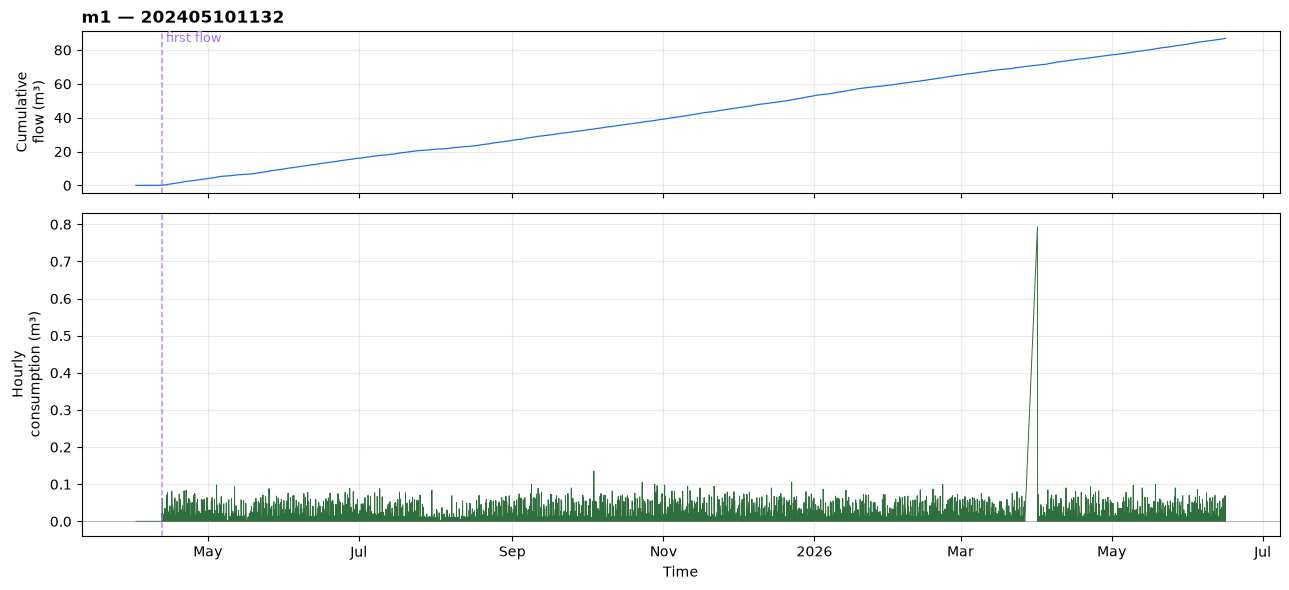

In [14]:
from src.plotting import plot_meter

plot_meter(m1, title="m1 — 202405101132")

(<Figure size 1300x600 with 2 Axes>,
 (<Axes: title={'left': 'm2 — 202405101935'}, ylabel='Cumulative\nflow (m³)'>,
  <Axes: xlabel='Time', ylabel='Hourly\nconsumption (m³)'>))

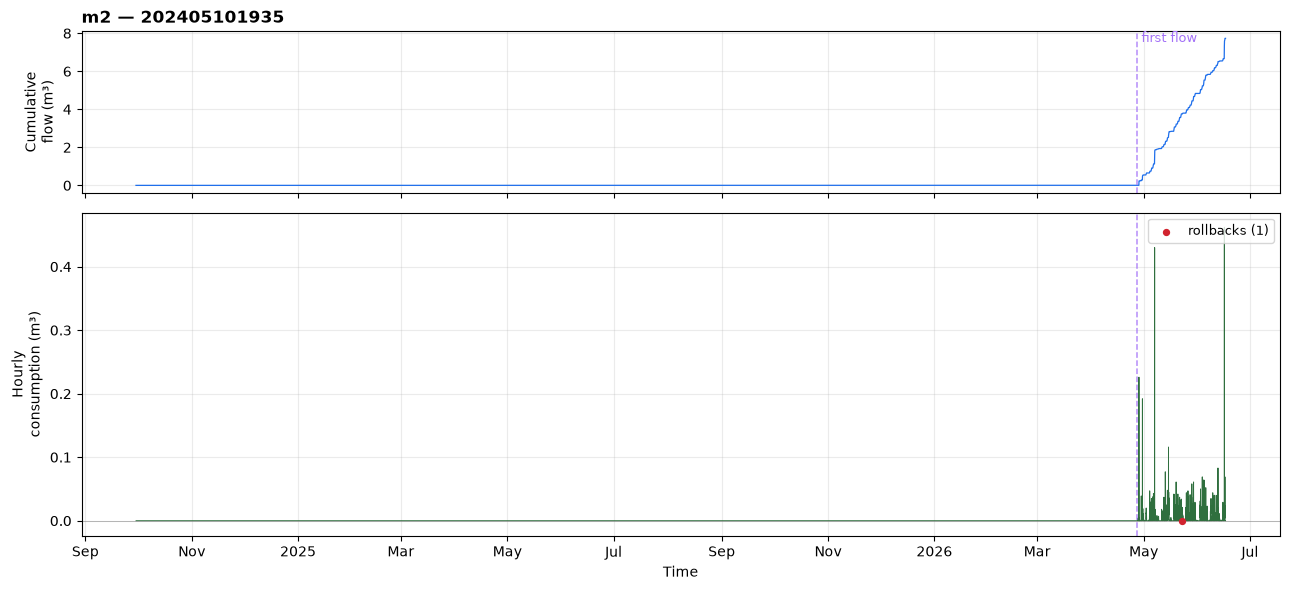

In [15]:
from src.plotting import plot_meter

plot_meter(m2, title="m2 — 202405101935")

(<Figure size 1300x600 with 2 Axes>,
 (<Axes: title={'left': 'm3 — 202405101899'}, ylabel='Cumulative\nflow (m³)'>,
  <Axes: xlabel='Time', ylabel='Hourly\nconsumption (m³)'>))

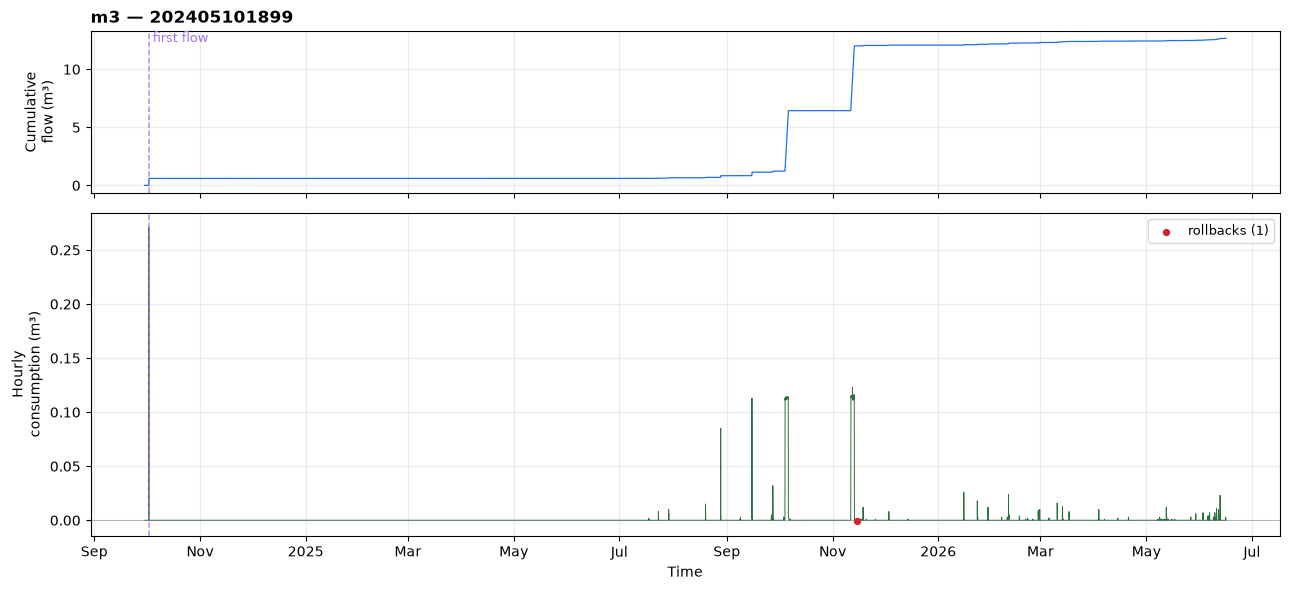

In [17]:
from src.plotting import plot_meter

plot_meter(m3, title="m3 — 202405101899")

(<Figure size 1300x600 with 2 Axes>,
 (<Axes: title={'left': 'm4 — 202405100909'}, ylabel='Cumulative\nflow (m³)'>,
  <Axes: xlabel='Time', ylabel='Hourly\nconsumption (m³)'>))

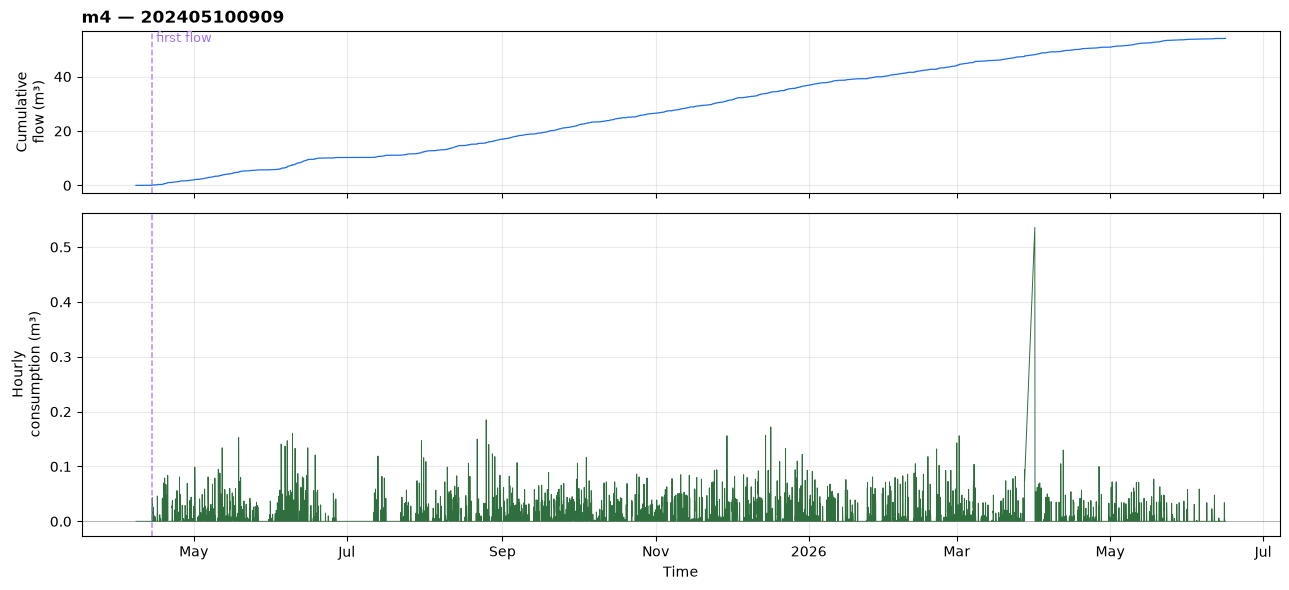

In [18]:
from src.plotting import plot_meter

plot_meter(m4, title="m4 — 202405100909")

(<Figure size 1300x600 with 2 Axes>,
 (<Axes: title={'left': 'm5 — 202405101891'}, ylabel='Cumulative\nflow (m³)'>,
  <Axes: xlabel='Time', ylabel='Hourly\nconsumption (m³)'>))

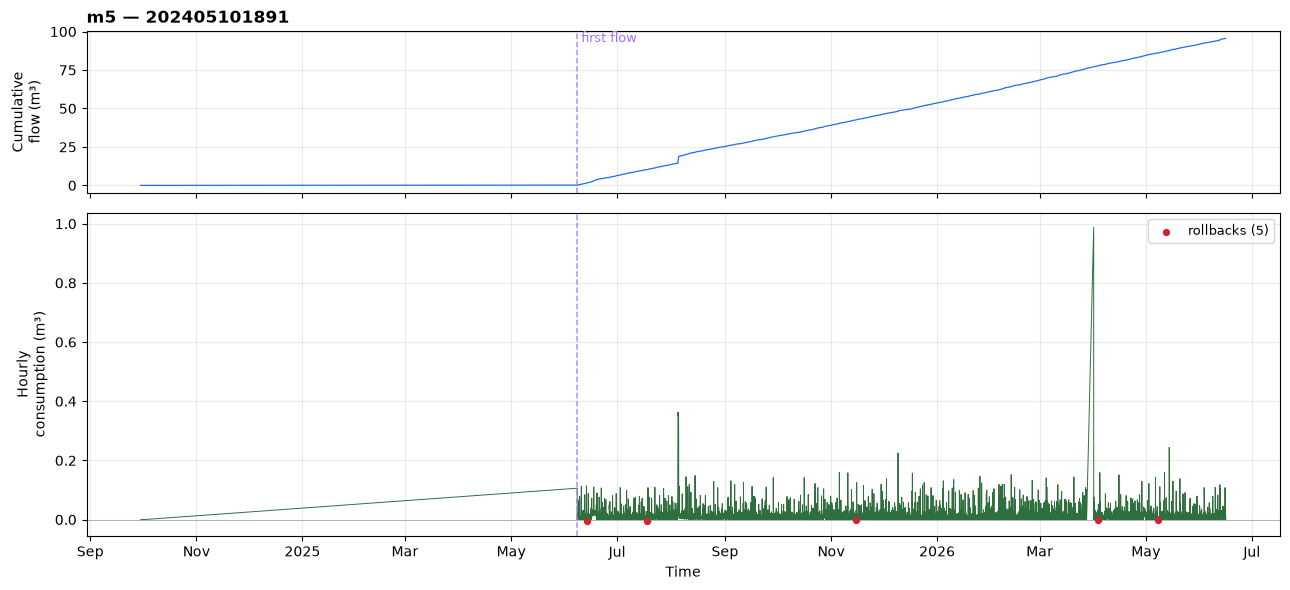

In [19]:
from src.plotting import plot_meter

plot_meter(m5, title="m5 — 202405101891")

In [20]:
from src.cleaning import clean_meter, report_table

results = [clean_meter(m) for m in [m1, m2, m3, m4, m5]]

# the cleaned series for the first meter:
results[0].df.head()

# data-quality report across all five (one row per meter):
report_table(results)

,rows_raw,rows_after_trim,commissioning_rows_dropped,first_flow,rows_final,rollbacks,gaps_filled,zero_consumption_hours,nonzero_consumption_hours,nan_consumption_hours,zero_rate,consumption_mean,consumption_max
device_id,,,,,,,,,,,,,
202405101132,10441,10190,251,2025-04-12T12:00:00,10309,0,119,5163,5026,120,0.501,0.0085,0.792
202405101935,8016,1213,6803,2026-04-27T12:00:00,1213,1,0,821,390,2,0.677,0.0064,0.462
202405101899,7992,7934,58,2024-10-02T11:00:00,14918,1,6984,7574,358,6986,0.508,0.0016,0.271
202405100909,10314,10160,154,2025-04-14T11:00:00,10262,0,102,7115,3044,103,0.693,0.0053,0.536
202405101891,8904,8856,48,2025-06-08T01:00:00,8952,5,96,2195,6655,102,0.245,0.0108,0.988


In [21]:
from src.cleaning import clean_meter, report_table

meters = {"202405101132": m1, "202405101935": m2, "202405101899": m3,
          "202405100909": m4, "202405101891": m5}

results = []
for device_id, df in meters.items():
    res = clean_meter(df)
    res.df.to_csv(f"../data/processed/clean_{device_id}.csv")
    results.append(res)

report_table(results)   # your data-quality table

,rows_raw,rows_after_trim,commissioning_rows_dropped,first_flow,rows_final,rollbacks,gaps_filled,zero_consumption_hours,nonzero_consumption_hours,nan_consumption_hours,zero_rate,consumption_mean,consumption_max
device_id,,,,,,,,,,,,,
202405101132,10441,10190,251,2025-04-12T12:00:00,10309,0,119,5163,5026,120,0.501,0.0085,0.792
202405101935,8016,1213,6803,2026-04-27T12:00:00,1213,1,0,821,390,2,0.677,0.0064,0.462
202405101899,7992,7934,58,2024-10-02T11:00:00,14918,1,6984,7574,358,6986,0.508,0.0016,0.271
202405100909,10314,10160,154,2025-04-14T11:00:00,10262,0,102,7115,3044,103,0.693,0.0053,0.536
202405101891,8904,8856,48,2025-06-08T01:00:00,8952,5,96,2195,6655,102,0.245,0.0108,0.988


In [22]:
report_table(results).to_csv("../reports/data_quality_week2.csv")

In [28]:
# if results is still in memory from running clean_meter:
checks = {r.device_id: r.df for r in results}

# or reload from disk:
import glob, pandas as pd
checks = {}
for f in glob.glob("../data/processed/clean_*.csv"):
    df = pd.read_csv(f, index_col=0, parse_dates=True)
    checks[df["deviceId"].iloc[0]] = df


In [29]:
for dev, df in checks.items():
    n_neg = (df["consumption"] < 0).sum()
    print(f"{dev}: negative consumption = {n_neg}")

202405100909.0: negative consumption = 0
202405101899.0: negative consumption = 0
202405101132.0: negative consumption = 0
202405101935: negative consumption = 0
202405101891.0: negative consumption = 0


In [30]:
for dev, df in checks.items():
    start = df.index.min()
    # how many leading zero-consumption hours at the very start?
    cons = df["consumption"].dropna()
    leading_zeros = (cons.cumsum() == 0).sum()  # zeros before any usage
    print(f"{dev}: starts {start}, leading zero-hours = {leading_zeros}")

202405100909.0: starts 2025-04-14 11:00:00, leading zero-hours = 0
202405101899.0: starts 2024-10-02 11:00:00, leading zero-hours = 0
202405101132.0: starts 2025-04-12 12:00:00, leading zero-hours = 0
202405101935: starts 2026-04-27 12:00:00, leading zero-hours = 19
202405101891.0: starts 2025-06-08 01:00:00, leading zero-hours = 1


In [31]:
for r in results:
    rep = r.report
    expected = rep["rows_after_trim"] + rep["gaps_filled"]
    print(f"{rep['device_id']}: after_trim+gaps={expected}, rows_final={rep['rows_final']}, match={expected==rep['rows_final']}")

202405101132: after_trim+gaps=10309, rows_final=10309, match=True
202405101935: after_trim+gaps=1213, rows_final=1213, match=True
202405101899: after_trim+gaps=14918, rows_final=14918, match=True
202405100909: after_trim+gaps=10262, rows_final=10262, match=True
202405101891: after_trim+gaps=8952, rows_final=8952, match=True


In [33]:
from src.events import emit_rollback_events, write_jsonl, validate_event

events = emit_rollback_events(results)          # results = your 5 CleanResults
print(f"{len(events)} rollback events")
assert all(not validate_event(e) for e in events)
write_jsonl(events, "../outputs/events/rollback_events.jsonl")

7 rollback events


7